## Lab 2: Differential Diagnosis and Conditional Expectation

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
import graphviz

# Load data
df = pd.read_csv('./data/ed_visits_probability_lab_train.csv')
test = pd.read_csv('./data/ed_visits_probability_lab_test.csv')


A differential diagnosis is when a health care provider uses the availability of information about different symptoms to try to narrow down the set of possible health problems a patient might be experiencing, before recommending further testing or treatment.

We are not doctors, but we do have the National Hospital Ambulatory Medical Care Survey. The version we will use is **heavily** cleaned and simplified for our lab, please do not use it for research or any other purposes.

Here are the key pieces, in `./data/ed_visits_probability_lab_train.csv` and `./data/ed_visits_probability_lab_test.csv` files both contain:
- The patient's International Classification of Diseases (ICD) code has been simplified in the `disease_group` variable, with 18 categories like `cardiovascular` or `neurological`.
- There are binary symptoms: 'abdominal_pain', 'cough',
       'vomiting', 'fever', 'nausea', 'chest_pain', 'shortness_of_breath',
       'headache', 'accident', 'dizziness', 'back_pain', 'anxiety',
       'skin_rash'
- There are some other variables that likely have predictive value: `sex`, `arrival_by_ambulance`, and age group bins for under 20, 20-40, 40-60, 60-70, and over 70.

Note that you might have a skin rash because you have seborrheic dermatitis, and the underlying condition is actually Parkinson's Disease, which is neurological in nature. Likewise, a person who arrives in an ambulance with chest pain might be having a heart attack, but a walk-in with slight pain might be having an aortic dissection. Just because you have one kind of symptom that is representative of one class of diseases doesn't rule out complex or unexpected causes.

We are going to use the Decision Tree Classifier to learn more about conditional expectation. **This is not a lab about machine learning.** The decision tree classifier splits the sample according to questions about symptoms as it moves through the tree, and computes a probability mass function at each step that represents the proportions of the remaining part of the population with each of the disease codes.

## Step 1:

Run the code below, installing `scikit-learn` and `graphviz` as necessary.

In [3]:
# Symptom variables
symptoms = [
    'abdominal_pain', 'cough', 'vomiting', 'fever', 'nausea',
    'chest_pain', 'shortness_of_breath', 'headache', 'accident',
    'dizziness', 'back_pain', 'anxiety', 'skin_rash',
]

# Patient-context variables
patient_vars = [
    'arrival_by_ambulance', 'sex',
    'age_u20', 'age_20_40', 'age_40_60', 'age_60_70', 'age_o70',
]

x_vars = symptoms + patient_vars

# Explanatory-variable matrices
X = df[x_vars].to_numpy()
X_test = test[x_vars].to_numpy()

print('Disease groups:')
print(df['disease_group'].value_counts())


Disease groups:
disease_group
injury_trauma               17711
general_constitutional       8048
other                        5924
ear_nose_throat_eye          4800
gastrointestinal             3911
genitourinary_renal          3796
respiratory                  3688
psychiatric_behavioral       3637
musculoskeletal              3430
infectious_disease           2988
cardiovascular               2320
endocrine_metabolic          2012
dermatologic                 1811
injury_adverse_care          1511
neurological                 1270
pregnancy_related            1237
injury_poisoning              779
hepatobiliary_pancreatic      618
Name: count, dtype: int64


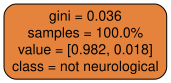

In [15]:
# Set outcome variable:
disease = 'neurological'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-3, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

The above object is a **decision tree classifier**: It predicts class labels on the basis of covariates. At each **node** in the graph, there is a condition, like `cough<=.5`. Depending on how the case evaluates, we move left (`True`) or right (`False`) down the tree along the **edges**. At each node, we also see the probability mass function, conditional on the current information set. At the bottom of the tree are **terminal leaves** with hard classification predictions and the final proportions.

The tree classifier pictured in the previous code chunk provides the probability mass function over the labels "not respiratory" and "respiratory". It starts as 95% of patients not having a respiratory problem, and 5% having a respiratory problem. The first differential diagnosis question is, "Does the patient have a cough?" If they do have a cough, we update our estimate to .73/.27, and if not, we update to .97/.03. If you have a cough, shortness of breath, you reach the highest estimate, .59/.41.

This is exactly what conditional probability and conditional expectation are: We update our beliefs based on evidence, and that reshapes our posterior estimates of the probabilities of different outcomes.

The probabilities displayed by the tree are fitted conditional estimates: they are the training-data class proportions among patients reaching each node. They are useful for this lab, but they are not calibrated clinical risk estimates.

<div class="alert alert-block alert-warning">

Which combinations of symptoms make a respiratory disease the most likely explanation? The least likely?

Which variables does the tree exploit? 

Clearly explain how the tree is a representation of conditional updating, where we condition on reported symptoms to provide new probability estimates based on new information.

Run the code again, but try values of 1e-3=0.001, 1e-5=0.00001 and 1e-7=0.0000001 for `min_impurity_decrease` to allow it to explore more complex explanations of the data. For each value of the `min_impurity_decrease` hyperparameter, find the terminal leaves with the lowest and highest probabilities of respiratory disease. How do these values vary with the complexity of the tree?

</div>

Answers:
1. Symptoms that make a respiratory disease most likely: Cough and shortness of breath (leads to estimate of 0.59/0.41)  
Symptoms that make a respiratory disease least likely: No cough, no fever, no shortness of breath (leads to estimate of 0.98/0.02)  

2. Cough, Shortness of Breath, Fever, Chest Pain, Dizziness, Arrival by Ambulance  

3. The tree ispredicting if a patient's diagnosis will be respiratory/non-respiratory as it adds new conditions (symptoms), where each new condition's probability is dependent on the ones before it. The tree starts with the overall proportions in the training data of 0.95/0.5 for non-respiratory patients and respiratory patients, and it creates its first node on what symptom most meaningfully separates these two classifications. The first node is cough, so the tree found that cough was the most meaningful separating symptom of the non-resp, resp label. So it then looks at people who reported true for having a cough and reported false for having a cough, and it finds the NEXT symptom that would be a meaningful split, and for both, its shortness of breath. At each node, the likelihood of the patient receiving a diagnosis of "non-respiratory" or "respiratory" is updated based on the conditions before it.  
So each node's conditional probability is dependent/conditional on what came before. For example, at each node, it has to take into account the probability of the symptoms of previous branches, so it starts at "what's the probability of the patient being labeled respiratory given they have a cough (p[respiratory | cough])" and then keeps narrowing the population, so then the next question is "what's the probability of a patient being labeled respiratory given they have a cough AND shortness of breath (p[respiratory | cough, shortness of breath])." As we receive more information (symptoms), we split the patients into narrower groups and update the probabilities accordingly (the previous probabilities matter because we are narrowing as we go).

4. *1e-3*: lowest probability is no cough -> no shortness of breath **[0.978/0.22]**; highest is yes cough **[0.725/0.225]**   
*1e-5*: lowest is no cough -> no shortness of breath -> no fever -> no chest pain -> no accident -> no age 20_40 -> no age 40_60 -> no arrival by ambulance **[0.978, 0.022]**;
highest is yes cough -> yes shortness of breath -> no chest pain -> no headache -> yes over 70 -> sex male **[0.445, 0.555]**  
*1e-7*: lowest is **[1, 0]**; highest is **[0.423, 0.577]**

Takeaways: In the least complex tree, the probabilities are not as extreme, whereas for the most complex tree, we had multiple terminal leaves with probabily [1,0], where patients with those symptoms were ALL non-respiratory. As it gets more complex, we allow for more splits, which eventually creates an outcome where there were NO patients with X,Y,Z symptoms labeled respiratory. Importantly, because our testing data has a split of 0.95/0.05 non-respiratory to respiratory, the probability of non-respiratory will always have much higher probabilities, due to how the number of cases differ. Even as we increased complexity, we only saw [0.423, 0.577] as the highest probability of respiratory, and this is heavily influenced by the fact that our respiratory sample is so small to begin with.

<div class="alert alert-block alert-warning">

Repeat the previous step with `disease = 'neurological'` and `min_impurity_decrease = 1e-3`. What variables are used in the tree? Which variables raise or lower the predicted probability of a neurological diagnosis?

</div>

Answers:  

1. For neurological at 1e-3, the tree did not create any nodes. It simply listed the distribution of our full sample, where not neurological has a probability of 0.982 and neurological had a probability of 0.018. There wasn't a way to split neurological patients that satisfied the constraints we added to the model.

## Step 2:

In step 1, we tried to predict whether a patient has a single condition or not. Now, we want to predict the entire probability mass function.

The code block sets `y = df['disease_group']` and `outcome = df['disease_group'].unique()`, and runs a similar analysis. The result is now a fitted differential diagnosis: an estimated probability mass function over the labels and a hard classification label. For readability, we set `max_depth = 3`.

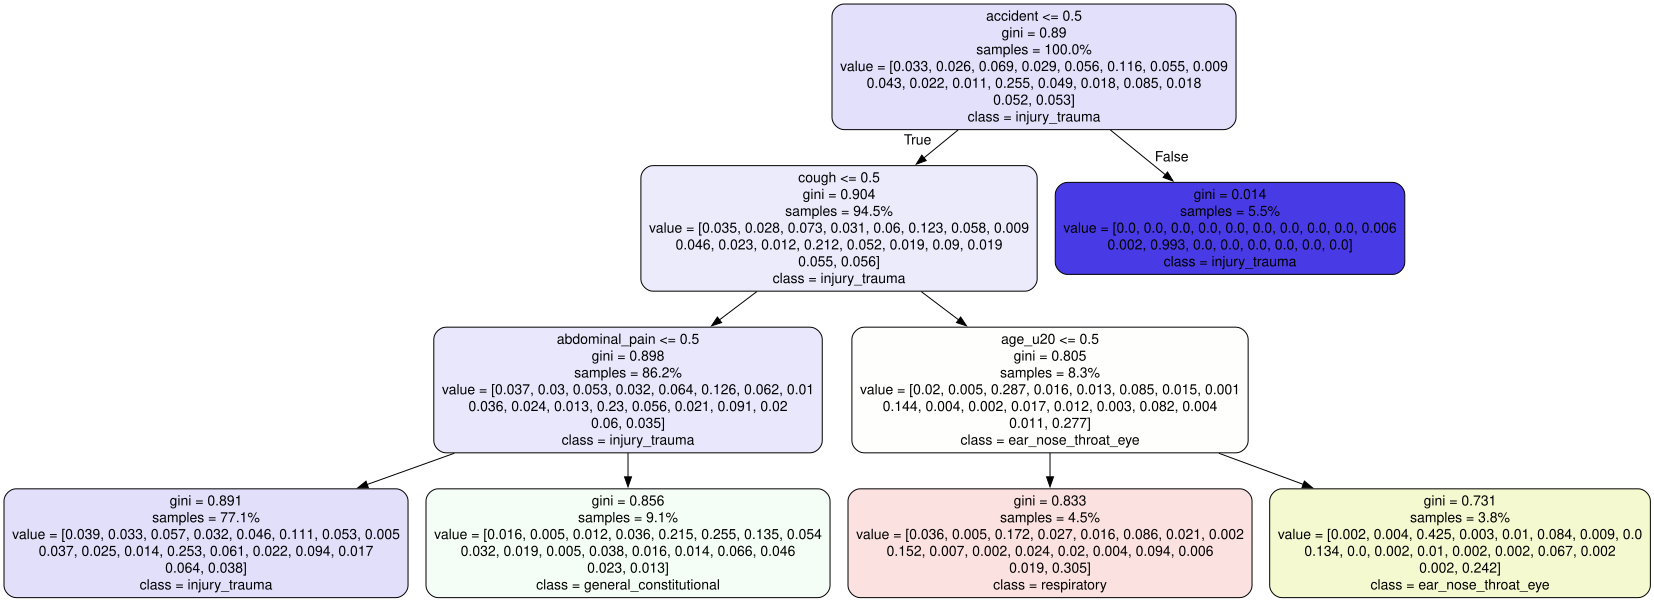

In [16]:
# Set outcome variable:
y = df['disease_group']
## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 3, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)


# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=model.classes_,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

<div class="alert alert-block alert-warning">

Which diseases are predicted as hard classifications in the tree? For those labels, does the probability of that disease exceed even a moderate value like .3 or .5, or not? Why might this be a concern?

Which labels have the highest or lowest probabilities for the predicted disease class labels? 

Which conditions and values are used in the tree?

Even if the probabilities for each terminal leaf remain fairly small in absolute terms, why can a differential diagnosis tool like this still be useful for doctors?

</div>

Answers:

1. Diseases labeled as hard classifications: injury_trauma, ear_nose_throat_eye, general_constitutional, respiratory  
Most labels fall between 0.2 and 0.3, except for patients who suffered an accident, where injury_trauma had 0.993. These low values can be a concern because we don't have 

2. injury_trauma has the highest probability at 0.993 for patients with accident - yes. 

3. The conditions for our tree are accident, cough, abdominal pain, and age under 20.  

4. A differential diagnosis tool with small terminal leafs is still useful because